# Save and Export

## Saving the analysis

Both the [`sainsc.LazyKDE`](#sainsc.LazyKDE) and [`sainsc.GridCounts`](#sainsc.GridCounts) classes can be serialized using the Python [`pickle`](#pickle) module. 
This way, you can always come back to where you left off.

In [34]:
import pickle

with open("my_analysis.pickle", "wb") as file:
    pickle.dump(my_analysis, file)

If you want to load it again just run ...

In [ ]:
import pickle

with open("my_analysis.pickle", "rb") as file:
    my_analysis = pickle.load(file)

## Exporting the local maxima

We will use the embryo dataset analysed with the signatures based on the cell segmentation from the {doc}`Celltyping tutorial <celltyping>` as a demonstration.

In [1]:
import pickle

with open("embryo.pickle", "rb") as file:
    embryo = pickle.load(file)

To export the local maxima we first have to identify them if it hasn't been done before.

In [2]:
embryo.find_local_maxima(4)

print(embryo)

LazyKDE (16 threads)
    genes: 28558
    shape: (27520, 17204)
    resolution: 500.0 nm / px
    kernel: (33, 33)
    background: set
    local maxima: 171862
    celltypes: 25


### AnnData

The local maxima can be exported as an AnnData object. Once you have identified them, you can load the KDE of specified genes (e.g., the genes used for cell typing).
If you have already performed celltyping as well, the corresponding information will be exported to the AnnData object too.

In [3]:
# here we will just randomly use the first 50 genes
localmax_adata = embryo.load_local_maxima(embryo.genes[:50])

print(localmax_adata)

AnnData object with n_obs × n_vars = 171862 × 50
    obs: 'total_mRNA_KDE', 'cosine_similarity', 'assignment_score', 'celltype'
    obsm: 'spatial'


### SpatialData

Alternatively, the local maxima can also be exported as a SpatialData object. 
In this case, the KDE of the specified genes will be loaded as an annotation to the local maxima positions (i.e., as a table in the SpatialData).
Additional information such as cell type and assignment score will be loaded as images or labels.

Furthermore, when loading as SpatialData, you can load the KDE of additional genes as a multi-channel image too. 
But keep in mind that loading many of those will require a lot of memory/disk space.

To follow along, you must install `spatialdata` and `spatialdata-plot`. 

In [4]:
# again we will randomly use the first 50 genes for the local maxima
# as well as a few genes for additional KDE images

localmax_sdata = embryo.load_local_maxima(
    embryo.genes[:50],
    spatialdata=True,
    img_genes=["Hbb-bs", "Ttr", "Tuba1a", "Myl3", "Acta2"],
)

localmax_sdata

/dh-projects/ag-ishaque/analysis/muellni/envs/sainsc_dev/lib/python3.11/functools.py:946: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return method.__get__(obj, cls)(*args, **kwargs)


SpatialData object
├── Images
│     ├── 'KDE_genes': DataArray[cyx] (5, 17204, 27520)
│     ├── 'assignment_score': DataArray[cyx] (1, 17204, 27520)
│     ├── 'cosine_similarity': DataArray[cyx] (1, 17204, 27520)
│     └── 'total_mRNA_KDE': DataArray[cyx] (1, 17204, 27520)
├── Labels
│     └── 'celltype_map': DataArray[yx] (17204, 27520)
├── Points
│     └── 'local_maxima': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      ├── 'celltype_map_annotation': AnnData (25, 0)
      └── 'local_maxima_annotation': AnnData (171862, 50)
with coordinate systems:
    ▸ 'global', with elements:
        KDE_genes (Images), assignment_score (Images), cosine_similarity (Images), total_mRNA_KDE (Images), celltype_map (Labels), local_maxima (Points)

You can use standard SpatialData plotting functions now ...

The `scalebar_dx` parameter corresponds to the resolution of our LazyKDE object, i.e., 0.5 µm per pixel.

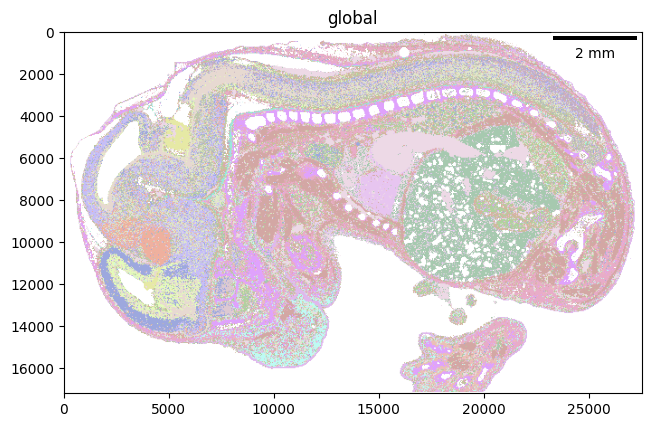

In [5]:
import spatialdata_plot

localmax_sdata.pl.render_labels(element="celltype_map").pl.show(scalebar_dx=0.5)

The 5 channels of the 'KDE_genes' image correspond to the 5 genes loaded as additional KDE images and can be accessed by name.

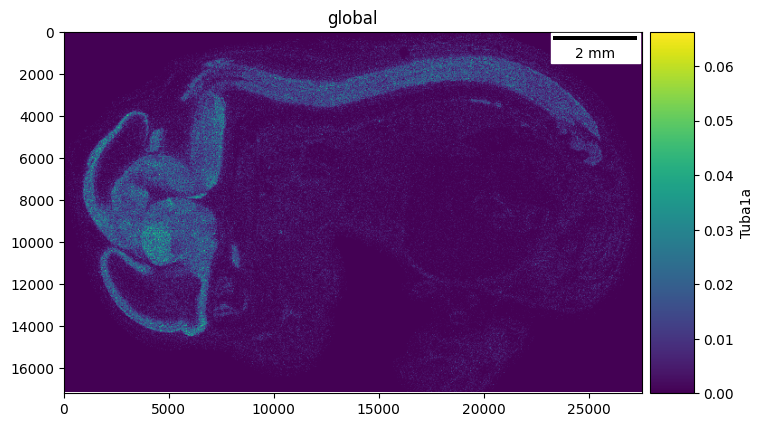

In [6]:
localmax_sdata.pl.render_images(element="KDE_genes", channel="Tuba1a").pl.show(
    scalebar_dx=0.5
)

Refer to the [SpatialData documentation](https://spatialdata.scverse.org/projects/plot/page/) for more information.